# 1. Setup

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

DATA_DIR = Path("data")

gov = pd.read_csv(DATA_DIR / "gov_channels_resolved.csv")
channel_videos = pd.read_csv(DATA_DIR / "channel_videos.csv")
eng = pd.read_csv(DATA_DIR / "engagement_timeseries.csv")
mostpop = pd.read_csv(DATA_DIR / "mostpopular_timeseries.csv")
meta = pd.read_csv(DATA_DIR / "videos_metadata_latest.csv")

print("gov:", gov.shape)
print("channel_videos:", channel_videos.shape)
print("eng:", eng.shape)
print("mostpop:", mostpop.shape)
print("meta:", meta.shape)

gov: (15, 4)
channel_videos: (1512, 3)
eng: (12903, 5)
mostpop: (450, 6)
meta: (1512, 9)


# 2. Load Data

In [44]:
for name, df in {
    "gov": gov,
    "channel_videos": channel_videos,
    "eng": eng,
    "mostpop": mostpop,
    "meta": meta
}.items():
    print(f"\n===== {name} =====")
    print("columns:", df.columns.tolist())
    print(df.head(3))


===== gov =====
columns: ['agency', 'channel_handle', 'channel_url', 'channel_id']
       agency channel_handle                          channel_url  \
0         CDC        @CDCgov      https://www.youtube.com/@CDCgov   
1        NASA          @NASA        https://www.youtube.com/@NASA   
2  WhiteHouse    @WhiteHouse  https://www.youtube.com/@WhiteHouse   

                 channel_id  
0                       NaN  
1  UCLA_DiR1FfKNvjuUpBHmylQ  
2  UCYxRlFDqcWM4y7FfpiAN3KQ  

===== channel_videos =====
columns: ['agency', 'channel_id', 'video_id']
  agency                channel_id     video_id
0   NASA  UCLA_DiR1FfKNvjuUpBHmylQ  GzWzo0AXmTg
1   NASA  UCLA_DiR1FfKNvjuUpBHmylQ  V0oo_Nybo6w
2   NASA  UCLA_DiR1FfKNvjuUpBHmylQ  glb4RtTwL40

===== eng =====
columns: ['video_id', 'snapshot_time_utc', 'viewCount', 'likeCount', 'commentCount']
      video_id                 snapshot_time_utc  viewCount  likeCount  \
0  tTs799cmxBc  2026-01-20T11:37:45.466150+00:00     116793     2849.0   
1  

## 3. Clean Column Names

In [45]:
import re

def to_snake(name):
    name = name.strip()
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)   # viewCount -> view_Count
    name = name.replace(" ", "_").replace("-", "_")
    return name.lower()

def clean_columns(df):
    df = df.copy()
    df.columns = [to_snake(c) for c in df.columns]
    return df

gov = clean_columns(gov)
channel_videos = clean_columns(channel_videos)
eng = clean_columns(eng)
mostpop = clean_columns(mostpop)
meta = clean_columns(meta)

print("gov:", gov.columns.tolist())
print("channel_videos:", channel_videos.columns.tolist())
print("eng:", eng.columns.tolist())
print("mostpop:", mostpop.columns.tolist())
print("meta:", meta.columns.tolist())

gov: ['agency', 'channel_handle', 'channel_url', 'channel_id']
channel_videos: ['agency', 'channel_id', 'video_id']
eng: ['video_id', 'snapshot_time_utc', 'view_count', 'like_count', 'comment_count']
mostpop: ['snapshot_time_utc', 'region', 'rank', 'video_id', 'channel_id', 'title']
meta: ['video_id', 'snapshot_time_utc', 'published_at', 'channel_id', 'title', 'category_id', 'view_count', 'like_count', 'comment_count']


## 4. Parse Datetime

In [46]:
ENG_TIME_COL = "snapshot_time_utc"
PUBLISHED_COL = "published_at"

eng[ENG_TIME_COL] = pd.to_datetime(eng[ENG_TIME_COL], errors="coerce", utc=True)
mostpop[ENG_TIME_COL] = pd.to_datetime(mostpop[ENG_TIME_COL], errors="coerce", utc=True)
meta[PUBLISHED_COL] = pd.to_datetime(meta[PUBLISHED_COL], errors="coerce", utc=True)

print("eng:")
print(eng[[ENG_TIME_COL]].head())
print(eng[ENG_TIME_COL].dtype)

print("\nmostpop:")
print(mostpop[[ENG_TIME_COL]].head())
print(mostpop[ENG_TIME_COL].dtype)

print("\nmeta:")
print(meta[[PUBLISHED_COL]].head())
print(meta[PUBLISHED_COL].dtype)

eng:
                 snapshot_time_utc
0 2026-01-20 11:37:45.466150+00:00
1 2026-01-20 11:37:45.466150+00:00
2 2026-01-20 11:37:45.466150+00:00
3 2026-01-20 11:37:45.466150+00:00
4 2026-01-20 11:37:45.466150+00:00
datetime64[ns, UTC]

mostpop:
                 snapshot_time_utc
0 2026-01-20 11:37:45.466150+00:00
1 2026-01-20 11:37:45.466150+00:00
2 2026-01-20 11:37:45.466150+00:00
3 2026-01-20 11:37:45.466150+00:00
4 2026-01-20 11:37:45.466150+00:00
datetime64[ns, UTC]

meta:
               published_at
0 2026-01-22 14:02:15+00:00
1 2026-01-21 23:34:25+00:00
2 2026-01-21 20:06:48+00:00
3 2026-01-20 19:41:30+00:00
4 2026-01-17 14:44:16+00:00
datetime64[ns, UTC]


## 5. Merge Engagement with Metadata

In [47]:
VIDEO_ID_COL = "video_id"
PUBLISHED_COL = "published_at"
ENG_TIME_COL = "snapshot_time_utc"

meta_keep = meta[[VIDEO_ID_COL, PUBLISHED_COL]].drop_duplicates(subset=[VIDEO_ID_COL])

eng = eng.merge(
    meta_keep,
    on=VIDEO_ID_COL,
    how="left"
)

eng["hours_since_publish"] = (
    (eng[ENG_TIME_COL] - eng[PUBLISHED_COL]).dt.total_seconds() / 3600
)

eng = eng[eng["hours_since_publish"].notna()].copy()
eng = eng.sort_values([VIDEO_ID_COL, ENG_TIME_COL]).reset_index(drop=True)

print(eng.shape)
print(eng[[VIDEO_ID_COL, ENG_TIME_COL, PUBLISHED_COL, "hours_since_publish"]].head(10))

(12688, 7)
      video_id                snapshot_time_utc              published_at  \
0  -0G2dxOhhtk 2026-01-20 11:37:45.466150+00:00 2025-01-11 23:31:42+00:00   
1  -0G2dxOhhtk 2026-01-20 11:38:20.143867+00:00 2025-01-11 23:31:42+00:00   
2  -0G2dxOhhtk 2026-01-20 11:40:13.538071+00:00 2025-01-11 23:31:42+00:00   
3  -0G2dxOhhtk 2026-01-21 15:20:23.673488+00:00 2025-01-11 23:31:42+00:00   
4  -0G2dxOhhtk 2026-01-21 15:21:41.407723+00:00 2025-01-11 23:31:42+00:00   
5  -0G2dxOhhtk 2026-01-22 20:18:52.076790+00:00 2025-01-11 23:31:42+00:00   
6  -0G2dxOhhtk 2026-01-22 20:19:16.873767+00:00 2025-01-11 23:31:42+00:00   
7  -0G2dxOhhtk 2026-01-23 18:27:01.013476+00:00 2025-01-11 23:31:42+00:00   
8  -0G2dxOhhtk 2026-01-24 03:15:56.686784+00:00 2025-01-11 23:31:42+00:00   
9  -6D4BNpBtVM 2026-01-20 11:37:45.466150+00:00 2025-05-22 20:10:52+00:00   

   hours_since_publish  
0          8964.100963  
1          8964.110596  
2          8964.142094  
3          8991.811576  
4          8991.

## 6. Build Latest Snapshot Dataset

In [48]:
VIDEO_ID_COL = "video_id"
ENG_TIME_COL = "snapshot_time_utc"

# lấy snapshot mới nhất của mỗi video
eng_latest = (
    eng.sort_values([VIDEO_ID_COL, ENG_TIME_COL])
       .groupby(VIDEO_ID_COL, as_index=False)
       .tail(1)
       .copy()
)

print("eng_latest shape:", eng_latest.shape)
print("unique videos in eng_latest:", eng_latest[VIDEO_ID_COL].nunique())

display(
    eng_latest[
        [VIDEO_ID_COL, ENG_TIME_COL, "view_count", "like_count", "comment_count", "hours_since_publish"]
    ].head(10)
)

eng_latest shape: (1512, 7)
unique videos in eng_latest: 1512


,video_id,snapshot_time_utc,view_count,like_count,comment_count,hours_since_publish
8,-0G2dxOhhtk,2026-01-24 03:15:56.686784+00:00,838,NaN,NaN,9051.737413
17,-6D4BNpBtVM,2026-01-24 03:15:56.686784+00:00,1845,NaN,NaN,5911.084635
26,-E2lv_NaETU,2026-01-24 03:15:56.686784+00:00,42,NaN,NaN,2965.146302
35,-FgAqMSgvIY,2026-01-24 03:15:56.686784+00:00,53493,348.0,NaN,6564.078802
44,-Ijn-W6VAPw,2026-01-24 03:15:56.686784+00:00,96810,2530.0,NaN,1033.523802
48,-JK3hSFA_60,2026-01-24 03:15:56.686784+00:00,4877,44.0,NaN,109305.492969
57,-_2pv_FirQw,2026-01-24 03:15:56.686784+00:00,5043,NaN,NaN,7330.900191
66,-dTBkEoB4IU,2026-01-24 03:15:56.686784+00:00,2155,NaN,NaN,5599.100191
75,-iieQ4bx9j0,2026-01-24 03:15:56.686784+00:00,239,NaN,NaN,10958.858802
84,-mSwvoWMvHI,2026-01-24 03:15:56.686784+00:00,7911,223.0,14.0,19423.103524


## 7. Create Label and Merge into Latest Snapshot Dataset

In [49]:
VIDEO_ID_COL = "video_id"

top_threshold = meta["view_count"].quantile(0.90)

meta_label = meta[[VIDEO_ID_COL, "view_count"]].copy()
meta_label["label"] = (meta_label["view_count"] >= top_threshold).astype(int)

dataset = eng_latest.merge(
    meta_label[[VIDEO_ID_COL, "label"]],
    on=VIDEO_ID_COL,
    how="left"
)

print("Top 10% threshold:", top_threshold)
print("\ndataset shape:", dataset.shape)
print("\nLabel counts:")
print(dataset["label"].value_counts(dropna=False))
print("\nLabel ratio:")
print(dataset["label"].value_counts(normalize=True, dropna=False))

display(
    dataset[
        [VIDEO_ID_COL, "view_count", "like_count", "comment_count", "hours_since_publish", "label"]
    ].head(10)
)

Top 10% threshold: 146411.7

dataset shape: (1512, 8)

Label counts:
label
0    1360
1     152
Name: count, dtype: int64

Label ratio:
label
0    0.899471
1    0.100529
Name: proportion, dtype: float64


,video_id,view_count,like_count,comment_count,hours_since_publish,label
0,-0G2dxOhhtk,838,NaN,NaN,9051.737413,0
1,-6D4BNpBtVM,1845,NaN,NaN,5911.084635,0
2,-E2lv_NaETU,42,NaN,NaN,2965.146302,0
3,-FgAqMSgvIY,53493,348.0,NaN,6564.078802,0
4,-Ijn-W6VAPw,96810,2530.0,NaN,1033.523802,0
5,-JK3hSFA_60,4877,44.0,NaN,109305.492969,0
6,-_2pv_FirQw,5043,NaN,NaN,7330.900191,0
7,-dTBkEoB4IU,2155,NaN,NaN,5599.100191,0
8,-iieQ4bx9j0,239,NaN,NaN,10958.858802,0
9,-mSwvoWMvHI,7911,223.0,14.0,19423.103524,0


## 8. Build Safe Feature Set

In [50]:
dataset_model = dataset.copy()

# fill missing
dataset_model["like_count"] = dataset_model["like_count"].fillna(0)
dataset_model["comment_count"] = dataset_model["comment_count"].fillna(0)

# log features
dataset_model["log_like_count"] = np.log1p(dataset_model["like_count"])
dataset_model["log_comment_count"] = np.log1p(dataset_model["comment_count"])
dataset_model["log_hours_since_publish"] = np.log1p(dataset_model["hours_since_publish"])

feature_cols = [
    "like_count",
    "comment_count",
    "hours_since_publish",
    "log_like_count",
    "log_comment_count",
    "log_hours_since_publish"
]

print("Missing values in selected features:")
print(dataset_model[feature_cols + ["label"]].isnull().sum())

print("\nFeature preview:")
display(dataset_model[feature_cols + ["label"]].head(10))

Missing values in selected features:
like_count                 0
comment_count              0
hours_since_publish        0
log_like_count             0
log_comment_count          0
log_hours_since_publish    0
label                      0
dtype: int64

Feature preview:


,like_count,comment_count,hours_since_publish,log_like_count,log_comment_count,log_hours_since_publish,label
0,0.0,0.0,9051.737413,0.000000,0.00000,9.110822,0
1,0.0,0.0,5911.084635,0.000000,0.00000,8.684754,0
2,0.0,0.0,2965.146302,0.000000,0.00000,7.995019,0
3,348.0,0.0,6564.078802,5.855072,0.00000,8.789520,0
4,2530.0,0.0,1033.523802,7.836370,0.00000,6.941697,0
5,44.0,0.0,109305.492969,3.806662,0.00000,11.601911,0
6,0.0,0.0,7330.900191,0.000000,0.00000,8.899990,0
7,0.0,0.0,5599.100191,0.000000,0.00000,8.630540,0
8,0.0,0.0,10958.858802,0.000000,0.00000,9.301995,0
9,223.0,14.0,19423.103524,5.411646,2.70805,9.874270,0


## 9. Train Test Split

In [51]:
from sklearn.model_selection import train_test_split

X = dataset_model[feature_cols].copy()
y = dataset_model["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train ratio:")
print(y_train.value_counts(normalize=True))

print("\ny_test ratio:")
print(y_test.value_counts(normalize=True))

X_train: (1209, 6)
X_test: (303, 6)

y_train ratio:
label
0    0.89909
1    0.10091
Name: proportion, dtype: float64

y_test ratio:
label
0    0.90099
1    0.09901
Name: proportion, dtype: float64


## 10. Train Logistic Regression

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 11. Evaluate Logistic Regression

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9372937293729373
Precision: 0.6410256410256411
Recall: 0.8333333333333334
F1: 0.7246376811594203
ROC-AUC: 0.9429792429792431

Confusion Matrix:
[[259  14]
 [  5  25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       273
           1       0.64      0.83      0.72        30

    accuracy                           0.94       303
   macro avg       0.81      0.89      0.84       303
weighted avg       0.95      0.94      0.94       303



## 12. Train XGBoost

In [54]:
from xgboost import XGBClassifier

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


## 13. Evaluate XGBoost

In [55]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_xgb, zero_division=0))
print("F1:", f1_score(y_test, y_pred_xgb, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Accuracy: 0.9504950495049505
Precision: 0.6923076923076923
Recall: 0.9
F1: 0.782608695652174
ROC-AUC: 0.9789987789987791

Confusion Matrix:
[[261  12]
 [  3  27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       273
           1       0.69      0.90      0.78        30

    accuracy                           0.95       303
   macro avg       0.84      0.93      0.88       303
weighted avg       0.96      0.95      0.95       303



## 14. Compare Logistic Regression and XGBoost

In [56]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.937294,0.641026,0.833333,0.724638,0.942979
1,XGBoost,0.950495,0.692308,0.900000,0.782609,0.978999


## 15. XGBoost Feature Importance

In [57]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,like_count,0.354897
3,log_like_count,0.279685
4,log_comment_count,0.116392
1,comment_count,0.109037
2,hours_since_publish,0.072284
5,log_hours_since_publish,0.067704


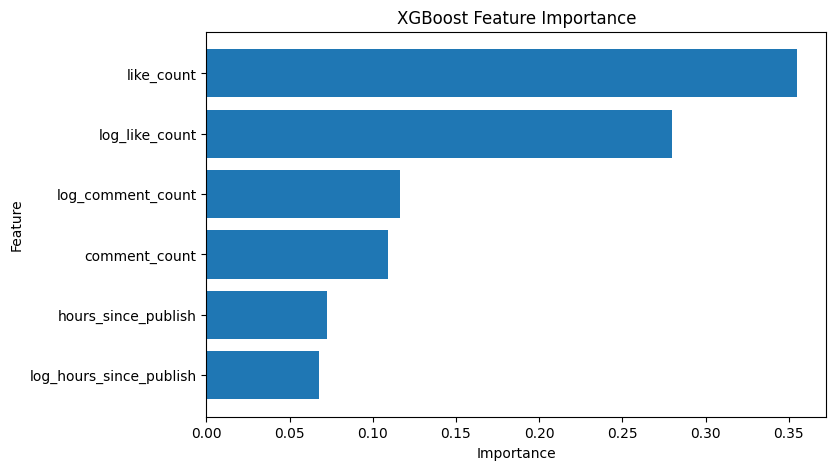

In [58]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## 16. SHAP Explanation for XGBoost

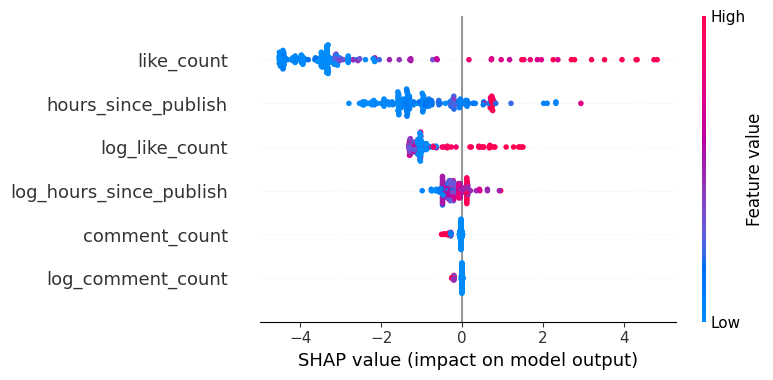

In [59]:
import shap

sample_X = X_test.sample(min(200, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X)

## 17. Save Results

In [60]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# lưu bảng so sánh model
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

# lưu feature importance
importance_df.to_csv(OUTPUT_DIR / "xgb_feature_importance.csv", index=False)

# lưu dự đoán test
pred_df = X_test.copy()
pred_df["y_true"] = y_test.values
pred_df["lr_pred"] = y_pred
pred_df["lr_prob"] = y_prob
pred_df["xgb_pred"] = y_pred_xgb
pred_df["xgb_prob"] = y_prob_xgb
pred_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print("Saved files:")
print("-", OUTPUT_DIR / "model_comparison.csv")
print("-", OUTPUT_DIR / "xgb_feature_importance.csv")
print("-", OUTPUT_DIR / "test_predictions.csv")

Saved files:
- outputs\model_comparison.csv
- outputs\xgb_feature_importance.csv
- outputs\test_predictions.csv


## 18. Export XGBoost Predictions

In [61]:
test_result = X_test.copy()
test_result["y_true"] = y_test.values
test_result["xgb_pred"] = y_pred_xgb
test_result["xgb_prob"] = y_prob_xgb

# lấy lại video_id bằng index gốc từ dataset_model
test_result = test_result.merge(
    dataset_model[["video_id"]],
    left_index=True,
    right_index=True,
    how="left"
)

cols = ["video_id"] + [c for c in test_result.columns if c != "video_id"]
test_result = test_result[cols]

print(test_result.head(10))
print("\nShape:", test_result.shape)

         video_id  like_count  comment_count  hours_since_publish  \
1241  pFLqcX7Kpnc        93.0            0.0          5794.729080   
130   4gDntIl2JSc      1747.0            0.0          8123.617413   
1475  yWYXSVkjMQY         0.0            0.0          4452.271857   
148   5QiXv8gVmeU      8117.0            0.0         21007.274357   
1391  v4fFs7X1AdM         0.0            0.0          9969.638524   
320   D-_UpmNP844      1937.0            0.0          6666.530746   
754   VDCBAwbrpuI       116.0            0.0         23025.414913   
597   OIAduLEqvTc      1340.0            0.0          1382.499080   
1473  yUxz2NGOV7k         0.0            0.0         12153.104357   
1157  lY0t9HI1Ves         0.0            0.0          4953.443246   

      log_like_count  log_comment_count  log_hours_since_publish  y_true  \
1241        4.543295                0.0                 8.664877       0   
130         7.466228                0.0                 9.002654       0   
1475        

## 19. Week 2 Setup (Sequence + Change-features + Burst)

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VIDEO_ID_COL = "video_id"
TIME_COL = "snapshot_time_utc"

VIEWS_COL = "view_count"
LIKES_COL = "like_count"
COMMENTS_COL = "comment_count"

K = 6  # số snapshot đầu để làm sequence (có thể đổi 4/6/8)

## 20. Build Sequence Window (first K snapshots per video)

In [63]:
# eng hiện tại đã có hours_since_publish + published_at rồi
# lọc giờ âm + fill NaN
eng_valid = eng[eng["hours_since_publish"] >= 0].copy()

for c in [VIEWS_COL, LIKES_COL, COMMENTS_COL]:
    eng_valid[c] = eng_valid[c].fillna(0)

eng_valid = eng_valid.sort_values([VIDEO_ID_COL, TIME_COL]).reset_index(drop=True)

# chỉ giữ những video có >= K snapshots
cnt = eng_valid.groupby(VIDEO_ID_COL).size()
keep_videos = cnt[cnt >= K].index

eng_k = eng_valid[eng_valid[VIDEO_ID_COL].isin(keep_videos)].copy()
eng_k = eng_k.groupby(VIDEO_ID_COL, as_index=False).head(K).copy()

# timestep 0..K-1
eng_k["t"] = eng_k.groupby(VIDEO_ID_COL).cumcount()

print("eng_k shape:", eng_k.shape)
print("videos covered:", eng_k[VIDEO_ID_COL].nunique())
print("timestep range:", eng_k["t"].min(), "->", eng_k["t"].max())
eng_k.head(10)

eng_k shape: (8052, 8)
videos covered: 1342
timestep range: 0 -> 5


,video_id,snapshot_time_utc,view_count,like_count,comment_count,published_at,hours_since_publish,t
0,-0G2dxOhhtk,2026-01-20 11:37:45.466150+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,8964.100963,0
1,-0G2dxOhhtk,2026-01-20 11:38:20.143867+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,8964.110596,1
2,-0G2dxOhhtk,2026-01-20 11:40:13.538071+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,8964.142094,2
3,-0G2dxOhhtk,2026-01-21 15:20:23.673488+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,8991.811576,3
4,-0G2dxOhhtk,2026-01-21 15:21:41.407723+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,8991.833169,4
5,-0G2dxOhhtk,2026-01-22 20:18:52.076790+00:00,838,0.0,0.0,2025-01-11 23:31:42+00:00,9020.786132,5
9,-6D4BNpBtVM,2026-01-20 11:37:45.466150+00:00,1756,0.0,0.0,2025-05-22 20:10:52+00:00,5823.448185,0
10,-6D4BNpBtVM,2026-01-20 11:38:20.143867+00:00,1757,0.0,0.0,2025-05-22 20:10:52+00:00,5823.457818,1
11,-6D4BNpBtVM,2026-01-20 11:40:13.538071+00:00,1757,0.0,0.0,2025-05-22 20:10:52+00:00,5823.489316,2
12,-6D4BNpBtVM,2026-01-21 15:20:23.673488+00:00,1792,0.0,0.0,2025-05-22 20:10:52+00:00,5851.158798,3


## 21. Change-aware Features (delta + growth)

In [64]:
eng_k = eng_k.sort_values([VIDEO_ID_COL, TIME_COL]).copy()

eng_k["delta_views"] = eng_k.groupby(VIDEO_ID_COL)[VIEWS_COL].diff().fillna(0)
eng_k["delta_likes"] = eng_k.groupby(VIDEO_ID_COL)[LIKES_COL].diff().fillna(0)
eng_k["delta_comments"] = eng_k.groupby(VIDEO_ID_COL)[COMMENTS_COL].diff().fillna(0)

eng_k["prev_views"] = eng_k.groupby(VIDEO_ID_COL)[VIEWS_COL].shift(1)
eng_k["growth_views"] = eng_k["delta_views"] / eng_k["prev_views"].replace(0, np.nan)
eng_k["growth_views"] = eng_k["growth_views"].fillna(0)

eng_k[[
    VIDEO_ID_COL, "t", VIEWS_COL, "delta_views", "growth_views", LIKES_COL, COMMENTS_COL
]].head(12)

,video_id,t,view_count,delta_views,growth_views,like_count,comment_count
0,-0G2dxOhhtk,0,838,0.0,0.000000,0.0,0.0
1,-0G2dxOhhtk,1,838,0.0,0.000000,0.0,0.0
2,-0G2dxOhhtk,2,838,0.0,0.000000,0.0,0.0
3,-0G2dxOhhtk,3,838,0.0,0.000000,0.0,0.0
4,-0G2dxOhhtk,4,838,0.0,0.000000,0.0,0.0
5,-0G2dxOhhtk,5,838,0.0,0.000000,0.0,0.0
9,-6D4BNpBtVM,0,1756,0.0,0.000000,0.0,0.0
10,-6D4BNpBtVM,1,1757,1.0,0.000569,0.0,0.0
11,-6D4BNpBtVM,2,1757,0.0,0.000000,0.0,0.0
12,-6D4BNpBtVM,3,1792,35.0,0.019920,0.0,0.0


## 22. Define Targets from Last Timestep (classification + regression)

In [65]:
# target = view_count ở timestep cuối (t = K-1)
last_ts = eng_k[eng_k["t"] == (K - 1)][[VIDEO_ID_COL, VIEWS_COL]].copy()
last_ts = last_ts.rename(columns={VIEWS_COL: "views_t_last"})

# proxy label: top 10% theo views_t_last
top_thr_seq = last_ts["views_t_last"].quantile(0.90)
last_ts["y_class"] = (last_ts["views_t_last"] >= top_thr_seq).astype(int)

# regression target: log(1+views)
last_ts["y_reg"] = np.log1p(last_ts["views_t_last"])

print("Top 10% threshold (views_t_last):", top_thr_seq)
print(last_ts["y_class"].value_counts())
last_ts.head()

Top 10% threshold (views_t_last): 165165.10000000065
y_class
0    1207
1     135
Name: count, dtype: int64


,video_id,views_t_last,y_class,y_reg
5,-0G2dxOhhtk,838,0,6.732211
14,-6D4BNpBtVM,1816,0,7.504942
23,-E2lv_NaETU,42,0,3.761200
32,-FgAqMSgvIY,53486,0,10.887194
41,-Ijn-W6VAPw,95638,0,11.468336


## 23. Burst Labeling (video-level) + Event Weights

In [66]:
burst_tbl = eng_k.groupby(VIDEO_ID_COL)["delta_views"].max().reset_index()
burst_tbl = burst_tbl.rename(columns={"delta_views": "burst_score"})

burst_thr = burst_tbl["burst_score"].quantile(0.90)
burst_tbl["has_burst"] = (burst_tbl["burst_score"] >= burst_thr).astype(int)

print("Burst threshold (top 10% max delta_views):", burst_thr)
print(burst_tbl["has_burst"].value_counts())

# sample weight (event-weighted loss dạng sample_weight)
burst_tbl["sample_weight"] = 1 + 2 * burst_tbl["has_burst"]  # 1 hoặc 3
burst_tbl.head()

Burst threshold (top 10% max delta_views): 177.70000000000027
has_burst
0    1207
1     135
Name: count, dtype: int64


,video_id,burst_score,has_burst,sample_weight
0,-0G2dxOhhtk,0.0,0,1
1,-6D4BNpBtVM,35.0,0,1
2,-E2lv_NaETU,0.0,0,1
3,-FgAqMSgvIY,12.0,0,1
4,-Ijn-W6VAPw,1394.0,1,3


## 24. Build Sequence Feature Table (pivot by timestep)

In [67]:
def pivot_feature(df, value_col, prefix):
    p = df.pivot(index=VIDEO_ID_COL, columns="t", values=value_col)
    p.columns = [f"{prefix}_t{int(c)}" for c in p.columns]
    return p


X_likes = pivot_feature(eng_k, LIKES_COL, "likes")
X_comments = pivot_feature(eng_k, COMMENTS_COL, "comments")
X_dv = pivot_feature(eng_k, "delta_views", "dviews")
X_gv = pivot_feature(eng_k, "growth_views", "gviews")

X_seq = pd.concat([X_likes, X_comments, X_dv, X_gv], axis=1).reset_index().fillna(0)

# merge targets + burst + weight
data_w2 = (
    X_seq
    .merge(last_ts[[VIDEO_ID_COL, "y_class", "y_reg", "views_t_last"]], on=VIDEO_ID_COL, how="inner")
    .merge(burst_tbl[[VIDEO_ID_COL, "has_burst", "burst_score", "sample_weight"]], on=VIDEO_ID_COL, how="left")
)

data_w2["has_burst"] = data_w2["has_burst"].fillna(0).astype(int)
data_w2["burst_score"] = data_w2["burst_score"].fillna(0)
data_w2["sample_weight"] = data_w2["sample_weight"].fillna(1)

print("data_w2 shape:", data_w2.shape)
print("class ratio:\n", data_w2["y_class"].value_counts(normalize=True))
data_w2.head()

data_w2 shape: (1342, 31)
class ratio:
 y_class
0    0.899404
1    0.100596
Name: proportion, dtype: float64


,video_id,likes_t0,likes_t1,likes_t2,likes_t3,likes_t4,likes_t5,comments_t0,comments_t1,comments_t2,comments_t3,comments_t4,comments_t5,dviews_t0,dviews_t1,dviews_t2,dviews_t3,dviews_t4,dviews_t5,gviews_t0,gviews_t1,gviews_t2,gviews_t3,gviews_t4,gviews_t5,y_class,y_reg,views_t_last,has_burst,burst_score,sample_weight
0,-0G2dxOhhtk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0,6.732211,838,0,0.0,1
1,-6D4BNpBtVM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35.0,0.0,24.0,0.0,0.000569,0.0,0.019920,0.0,0.013393,0,7.504942,1816,0,35.0,1
2,-E2lv_NaETU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0,3.761200,42,0,0.0,1
3,-FgAqMSgvIY,348.0,348.0,348.0,348.0,348.0,348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,10.0,0.0,0.000000,0.0,0.000224,0.0,0.000187,0,10.887194,53486,0,12.0,1
4,-Ijn-W6VAPw,2515.0,2515.0,2515.0,2515.0,2515.0,2520.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,251.0,0.0,1394.0,0.0,0.000000,0.0,0.002670,0.0,0.014791,0,11.468336,95638,1,1394.0,3


## 25. Train/Test Split 

In [68]:
from sklearn.model_selection import train_test_split

feature_cols_w2 = [c for c in data_w2.columns if c.startswith(("likes_", "comments_", "dviews_", "gviews_"))]

X = data_w2[feature_cols_w2].copy()
y = data_w2["y_class"].copy()
w = data_w2["sample_weight"].copy()

X_train2, X_test2, y_train2, y_test2, w_train2, w_test2 = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train2:", X_train2.shape, "X_test2:", X_test2.shape)
print("y_train2 ratio:\n", y_train2.value_counts(normalize=True))
print("y_test2 ratio:\n", y_test2.value_counts(normalize=True))

X_train2: (1073, 24) X_test2: (269, 24)
y_train2 ratio:
 y_class
0    0.899348
1    0.100652
Name: proportion, dtype: float64
y_test2 ratio:
 y_class
0    0.899628
1    0.100372
Name: proportion, dtype: float64


## 26. Base vs Event-Weighted + Metrics

In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def eval_bin(model, Xte, yte):
    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "AUC": roc_auc_score(yte, prob),
        "F1": f1_score(yte, pred, zero_division=0),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
    }

xgb_seq_base = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgb_seq_base.fit(X_train2, y_train2)
res_seq_base = eval_bin(xgb_seq_base, X_test2, y_test2)

xgb_seq_weighted = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgb_seq_weighted.fit(X_train2, y_train2, sample_weight=w_train2)
res_seq_weighted = eval_bin(xgb_seq_weighted, X_test2, y_test2)

print("Week2 Base:", res_seq_base)
print("Week2 Event-weighted:", res_seq_weighted)

Week2 Base: {'AUC': 0.9970921334557699, 'F1': 0.8979591836734694, 'Precision': 1.0, 'Recall': 0.8148148148148148}
Week2 Event-weighted: {'AUC': 0.9981634527089073, 'F1': 0.875, 'Precision': 1.0, 'Recall': 0.7777777777777778}


## 27. Ablation: Remove Change-features (no dviews/gviews)

In [70]:
ablate_cols = [c for c in feature_cols_w2 if not c.startswith(("dviews_", "gviews_"))]

Xa = data_w2[ablate_cols].copy()
ya = data_w2["y_class"].copy()
wa = data_w2["sample_weight"].copy()

Xa_tr, Xa_te, ya_tr, ya_te, wa_tr, wa_te = train_test_split(
    Xa, ya, wa,
    test_size=0.2,
    random_state=42,
    stratify=ya
)

xgb_seq_ablate = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgb_seq_ablate.fit(Xa_tr, ya_tr, sample_weight=wa_tr)
res_seq_ablate = eval_bin(xgb_seq_ablate, Xa_te, ya_te)

print("Week2 Ablation (no change-features):", res_seq_ablate)

Week2 Ablation (no change-features): {'AUC': 0.9592898683807773, 'F1': 0.6808510638297872, 'Precision': 0.8, 'Recall': 0.5925925925925926}


## 28. Week 2 Summary Table (Base vs Weighted vs Ablation)

In [71]:
week2_table = pd.DataFrame([
    {"Model": "Seq-XGB Base", **res_seq_base},
    {"Model": "Seq-XGB Event-weighted", **res_seq_weighted},
    {"Model": "Seq-XGB Ablation (no change)", **res_seq_ablate},
])

week2_table

,Model,AUC,F1,Precision,Recall
0,Seq-XGB Base,0.997092,0.897959,1.0,0.814815
1,Seq-XGB Event-weighted,0.998163,0.875000,1.0,0.777778
2,Seq-XGB Ablation (no change),0.959290,0.680851,0.8,0.592593


## 29. Multi-task (Regression): Predict log(views_t_last)

In [72]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

yreg = data_w2["y_reg"].copy()
Xr = data_w2[feature_cols_w2].copy()
wr = data_w2["sample_weight"].copy()

Xr_tr, Xr_te, yr_tr, yr_te, wr_tr, wr_te = train_test_split(
    Xr, yreg, wr,
    test_size=0.2,
    random_state=42
)

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb_reg.fit(Xr_tr, yr_tr, sample_weight=wr_tr)

pred_log = xgb_reg.predict(Xr_te)

mae = mean_absolute_error(yr_te, pred_log)
rmse = np.sqrt(mean_squared_error(yr_te, pred_log))

pred_views = np.expm1(pred_log)
true_views = np.expm1(yr_te.values)
mae_views = np.mean(np.abs(true_views - pred_views))

print("Regression (log-scale) MAE:", mae)
print("Regression (log-scale) RMSE:", rmse)
print("Regression MAE on views (original scale):", mae_views)

Regression (log-scale) MAE: 0.3599346720312338
Regression (log-scale) RMSE: 0.5445297587927814
Regression MAE on views (original scale): 19057.288432252444


## 30. Time-step Explanation + Pruning (Occlusion / TimeSHAP-like)

In [73]:
def mask_timestep(X_row, t, prefixes=("likes", "comments", "dviews", "gviews")):
    X_mask = X_row.copy()
    for p in prefixes:
        col = f"{p}_t{t}"
        if col in X_mask.columns:
            X_mask[col] = 0
    return X_mask

def timestep_importance_avg(model, X_sample, K):
    base_prob = model.predict_proba(X_sample)[:, 1]
    impacts = []
    for t in range(K):
        Xm = X_sample.copy()
        for p in ("likes", "comments", "dviews", "gviews"):
            col = f"{p}_t{t}"
            if col in Xm.columns:
                Xm[col] = 0
        prob_m = model.predict_proba(Xm)[:, 1]
        impacts.append(base_prob - prob_m)
    # mean impact per timestep
    mean_imp = np.array([imp.mean() for imp in impacts])
    return mean_imp

# lấy mẫu 200 dòng từ test để tính importance trung bình
X_sample = X_test2.sample(min(200, len(X_test2)), random_state=42)
mean_imp = timestep_importance_avg(xgb_seq_weighted, X_sample, K=K)

imp_ts = pd.DataFrame({"timestep": list(range(K)), "importance": mean_imp}).sort_values("importance", ascending=False)
imp_ts

,timestep,importance
2,2,0.031029
3,3,0.014746
0,0,0.005783
5,5,0.003195
1,1,0.003064
4,4,0.000733


## 31. Plot Timestep Importance + Pruning Top-3

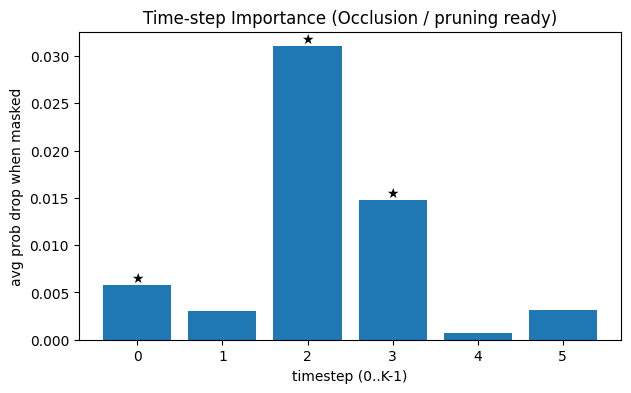

Top timesteps (pruned): [0, 2, 3]


In [74]:
imp_plot = imp_ts.sort_values("timestep").copy()

plt.figure(figsize=(7,4))
plt.bar(imp_plot["timestep"], imp_plot["importance"])
plt.xlabel("timestep (0..K-1)")
plt.ylabel("avg prob drop when masked")
plt.title("Time-step Importance (Occlusion / pruning ready)")

topk = 3
top_steps = set(imp_ts.head(topk)["timestep"].tolist())
for t in top_steps:
    yv = imp_plot.loc[imp_plot["timestep"] == t, "importance"].values[0]
    plt.text(t, yv, "★", ha="center", va="bottom")

plt.show()

print("Top timesteps (pruned):", sorted(list(top_steps)))

In [75]:
import os, json, subprocess
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
from datetime import datetime

def exists(varname: str) -> bool:
    return varname in globals()
summary = {
    "generated_at": datetime.now().isoformat(),
    "project": "GovTrendTube",
    "notes": "Auto-export from single notebook (Week1+Week2). No API keys included."
}

# thresholds if present
if exists("top_threshold"):
    summary["baseline_top10_threshold_view_count"] = float(top_threshold)
if exists("top_thr_seq"):
    summary["week2_top10_threshold_views_t_last"] = float(top_thr_seq)

# baseline metrics
if exists("comparison_df"):
    summary["baseline_model_comparison"] = comparison_df.to_dict(orient="records")

# top features
if exists("importance_df"):
    top_imp = importance_df.sort_values("importance", ascending=False).head(15)
    summary["xgb_top_features"] = top_imp.to_dict(orient="records")

# week2 results
if exists("week2_table"):
    summary["week2_models"] = week2_table.to_dict(orient="records")
if exists("imp_ts"):
    summary["week2_timestep_importance"] = imp_ts.sort_values("importance", ascending=False).to_dict(orient="records")

# dataset sizes if present
if exists("dataset"):
    summary["baseline_dataset_rows"] = int(len(dataset))
if exists("dataset_model"):
    summary["dataset_model_rows"] = int(len(dataset_model))
if exists("data_w2"):
    summary["week2_dataset_rows"] = int(len(data_w2))

summary_path = OUTPUT_DIR / "summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Saved:", summary_path)

# Export THIS notebook to HTML (optional)
# NOTE: replace NOTEBOOK_NAME with your current ipynb filename if different
NOTEBOOK_NAME = "notebook_baseline.ipynb"

cmd = [
    "jupyter", "nbconvert",
    "--to", "html",
    NOTEBOOK_NAME,
    "--output-dir", str(OUTPUT_DIR),
    "--output", Path(NOTEBOOK_NAME).stem + ".html"
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=False)

Saved: outputs\summary.json
Running: jupyter nbconvert --to html notebook_baseline.ipynb --output-dir outputs --output notebook_baseline.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'notebook_baseline.ipynb', '--output-dir', 'outputs', '--output', 'notebook_baseline.html'], returncode=1)

In [77]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from joblib import dump

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def exists(varname: str) -> bool:
    return varname in globals()

# Lưu baseline models
if exists("lr_model"):
    dump(lr_model, OUTPUT_DIR / "lr_model.joblib")
    print("Saved:", OUTPUT_DIR / "lr_model.joblib")

if exists("xgb_model"):
    dump(xgb_model, OUTPUT_DIR / "xgb_model.joblib")
    print("Saved:", OUTPUT_DIR / "xgb_model.joblib")

# Lưu feature columns baseline (dùng để predict)
# Nếu bạn đang dùng feature_cols cho baseline:
if exists("feature_cols"):
    with open(OUTPUT_DIR / "baseline_feature_cols.json", "w", encoding="utf-8") as f:
        json.dump(feature_cols, f, ensure_ascii=False, indent=2)
    print("Saved:", OUTPUT_DIR / "baseline_feature_cols.json")
else:
    # fallback đúng theo bạn đang dùng
    baseline_feature_cols = [
        "like_count","comment_count","hours_since_publish",
        "log_like_count","log_comment_count","log_hours_since_publish"
    ]
    with open(OUTPUT_DIR / "baseline_feature_cols.json", "w", encoding="utf-8") as f:
        json.dump(baseline_feature_cols, f, ensure_ascii=False, indent=2)
    print("Saved:", OUTPUT_DIR / "baseline_feature_cols.json (fallback)")

Saved: outputs\lr_model.joblib
Saved: outputs\xgb_model.joblib
Saved: outputs\baseline_feature_cols.json


In [78]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from joblib import dump

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def exists(varname: str) -> bool:
    return varname in globals()

# Lưu baseline models
if exists("lr_model"):
    dump(lr_model, OUTPUT_DIR / "lr_model.joblib")
    print("Saved:", OUTPUT_DIR / "lr_model.joblib")

if exists("xgb_model"):
    dump(xgb_model, OUTPUT_DIR / "xgb_model.joblib")
    print("Saved:", OUTPUT_DIR / "xgb_model.joblib")

# Lưu feature columns baseline (dùng để predict)
# Nếu bạn đang dùng feature_cols cho baseline:
if exists("feature_cols"):
    with open(OUTPUT_DIR / "baseline_feature_cols.json", "w", encoding="utf-8") as f:
        json.dump(feature_cols, f, ensure_ascii=False, indent=2)
    print("Saved:", OUTPUT_DIR / "baseline_feature_cols.json")
else:
    # fallback đúng theo bạn đang dùng
    baseline_feature_cols = [
        "like_count","comment_count","hours_since_publish",
        "log_like_count","log_comment_count","log_hours_since_publish"
    ]
    with open(OUTPUT_DIR / "baseline_feature_cols.json", "w", encoding="utf-8") as f:
        json.dump(baseline_feature_cols, f, ensure_ascii=False, indent=2)
    print("Saved:", OUTPUT_DIR / "baseline_feature_cols.json (fallback)")

Saved: outputs\lr_model.joblib
Saved: outputs\xgb_model.joblib
Saved: outputs\baseline_feature_cols.json


In [79]:
from pathlib import Path
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if exists("comparison_df"):
    comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
    print("Saved:", OUTPUT_DIR / "model_comparison.csv")

if exists("week2_table"):
    week2_table.to_csv(OUTPUT_DIR / "week2_model_table.csv", index=False)
    print("Saved:", OUTPUT_DIR / "week2_model_table.csv")

Saved: outputs\model_comparison.csv
Saved: outputs\week2_model_table.csv


In [80]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print("Saved:", OUTPUT_DIR / "model_comparison.csv")

Saved: outputs\model_comparison.csv


In [81]:
from pathlib import Path
import json

# luôn lưu vào outputs/ ở đúng thư mục project hiện tại
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

dataset_info = {
    "gov": {"shape": list(gov.shape), "columns": gov.columns.tolist()},
    "channel_videos": {"shape": list(channel_videos.shape), "columns": channel_videos.columns.tolist()},
    "eng": {"shape": list(eng.shape), "columns": eng.columns.tolist()},
    "mostpop": {"shape": list(mostpop.shape), "columns": mostpop.columns.tolist()},
    "meta": {"shape": list(meta.shape), "columns": meta.columns.tolist()},
}

dataset_info["meta"]["unique_videos"] = int(meta["video_id"].nunique())
dataset_info["eng"]["unique_videos"] = int(eng["video_id"].nunique())

out_path = OUTPUT_DIR / "dataset_info.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print("Saved:", out_path.resolve())

Saved: C:\Users\GIA HIEN\OneDrive\DAP391m - 2 weeks\outputs\dataset_info.json
